# Projet IA

## Loading Datasets Individualy

### Import libraries

In [77]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


In [78]:
df_employee = pd.read_csv(
    "./Data/employee_survey_data.csv",
    sep=",",
    header=0,
    names=["EmployeeID","EnvironmentSatisfaction","JobSatisfaction","WorkLifeBalance"]
)
df_general = pd.read_csv(
    "./Data/general_data.csv",
    sep=",",
    header=0,
    names=["Age","Attrition","BusinessTravel","Department","DistanceFromHome","Education","EducationField","EmployeeCount","EmployeeID","Gender","JobLevel","JobRole","MaritalStatus","MonthlyIncome","NumCompaniesWorked","Over18","PercentSalaryHike","StandardHours","StockOptionLevel","TotalWorkingYears","TrainingTimesLastYear","YearsAtCompany","YearsSinceLastPromotion","YearsWithCurrManager"]
)
df_manager = pd.read_csv(
    "./Data/manager_survey_data.csv",
    sep=",",
    header=0,
    names=["EmployeeID","JobInvolvement","PerformanceRating"]
)

### Informations about the datasets

In [79]:
print("-------------------- Employees --------------------")
print("-------------------- HEAD --------------------")
print(df_employee.head())
print("-------------------- DESCRIBE --------------------")
print(df_employee.describe())
print("-------------------- INFO --------------------")
print(df_employee.info())
print("-------------------- Missing Values --------------------")
print(df_employee.isnull().sum())
print("-------------------- Duplicates Values --------------------")
print(df_employee.duplicated().sum())
print("---------------------------------------------------")

-------------------- Employees --------------------
-------------------- HEAD --------------------
   EmployeeID  EnvironmentSatisfaction  JobSatisfaction  WorkLifeBalance
0           1                      3.0              4.0              2.0
1           2                      3.0              2.0              4.0
2           3                      2.0              2.0              1.0
3           4                      4.0              4.0              3.0
4           5                      4.0              1.0              3.0
-------------------- DESCRIBE --------------------
        EmployeeID  EnvironmentSatisfaction  JobSatisfaction  WorkLifeBalance
count  4410.000000              4385.000000      4390.000000      4372.000000
mean   2205.500000                 2.723603         2.728246         2.761436
std    1273.201673                 1.092756         1.101253         0.706245
min       1.000000                 1.000000         1.000000         1.000000
25%    1103.250000    

In [80]:
print("-------------------- General --------------------")
print("-------------------- HEAD --------------------")
print(df_general.head())
print("-------------------- DESCRIBE --------------------")
print(df_general.describe())
print("-------------------- INFO --------------------")
print(df_general.info())
print("-------------------- Missing Values --------------------")
print(df_general.isnull().sum())
print("-------------------- Duplicates Values --------------------")
print(df_general.duplicated().sum())
print("---------------------------------------------------")

-------------------- General --------------------
-------------------- HEAD --------------------
   Age Attrition     BusinessTravel              Department  DistanceFromHome  \
0   51        No      Travel_Rarely                   Sales                 6   
1   31       Yes  Travel_Frequently  Research & Development                10   
2   32        No  Travel_Frequently  Research & Development                17   
3   38        No         Non-Travel  Research & Development                 2   
4   32        No      Travel_Rarely  Research & Development                10   

   Education EducationField  EmployeeCount  EmployeeID  Gender  ...  \
0          2  Life Sciences              1           1  Female  ...   
1          1  Life Sciences              1           2  Female  ...   
2          4          Other              1           3    Male  ...   
3          5  Life Sciences              1           4    Male  ...   
4          1        Medical              1           5    Mal

In [81]:
print("-------------------- Managers --------------------")
print("-------------------- HEAD --------------------")
print(df_manager.head())
print("-------------------- DESCRIBE --------------------")
print(df_manager.describe())
print("-------------------- INFO --------------------")
print(df_manager.info())
print("-------------------- Missing Values --------------------")
print(df_manager.isnull().sum())
print("-------------------- Duplicates Values --------------------")
print(df_manager.duplicated().sum())
print("---------------------------------------------------")

-------------------- Managers --------------------
-------------------- HEAD --------------------
   EmployeeID  JobInvolvement  PerformanceRating
0           1               3                  3
1           2               2                  4
2           3               3                  3
3           4               2                  3
4           5               3                  3
-------------------- DESCRIBE --------------------
        EmployeeID  JobInvolvement  PerformanceRating
count  4410.000000     4410.000000        4410.000000
mean   2205.500000        2.729932           3.153741
std    1273.201673        0.711400           0.360742
min       1.000000        1.000000           3.000000
25%    1103.250000        2.000000           3.000000
50%    2205.500000        3.000000           3.000000
75%    3307.750000        3.000000           3.000000
max    4410.000000        4.000000           4.000000
-------------------- INFO --------------------
<class 'pandas.DataFrame

As we can see, the three dataframe are approximatly proper but we have to preprocess the df_general as it contains string data.

## Preprocessing of General

#### Encoding Categorical Variables

In [82]:
features_to_encode = ['Attrition','BusinessTravel','Department',
                      'EducationField','Gender','JobRole','MaritalStatus',
                      'Over18'
]
encoded = pd.get_dummies(df_general[features_to_encode], drop_first=True)
print(encoded.head())

   Attrition_Yes  BusinessTravel_Travel_Frequently  \
0          False                             False   
1           True                              True   
2          False                              True   
3          False                             False   
4          False                             False   

   BusinessTravel_Travel_Rarely  Department_Research & Development  \
0                          True                              False   
1                         False                               True   
2                         False                               True   
3                         False                               True   
4                          True                               True   

   Department_Sales  EducationField_Life Sciences  EducationField_Marketing  \
0              True                          True                     False   
1             False                          True                     False   
2             Fal

# Creating Integer variable

In [83]:
numeric_features = [
    "DistanceFromHome","Education","EmployeeCount","EmployeeID","JobLevel","MonthlyIncome","NumCompaniesWorked",
    "PercentSalaryHike","StandardHours","StockOptionLevel","TotalWorkingYears","TrainingTimesLastYear","YearsAtCompany","YearsSinceLastPromotion","YearsWithCurrManager"
]

In [84]:
# Convert Attrition to binary: Yes -> 1, No -> 0
df_general['Attrition_num'] = df_general['Attrition'].map({'Yes': 1, 'No': 0})

# Define your target
multi_y = df_general['Attrition_num']

# Preparing the Dataset

In [85]:
train_set = encoded.join(df_general[numeric_features])

# Splitting the Dataset

In [86]:
train_X, test_X,train_Y, test_Y = train_test_split(train_set, multi_y, test_size=0.2, random_state=1337)

## Creating a validation set

In [87]:
multi_train_X, multi_val_X, multi_train_Y, multi_val_Y = train_test_split(train_X, train_Y, test_size=0.3, random_state=1337)

In [88]:
# Train RandomForest model for multi-class classification
rf_model_multi = RandomForestClassifier(random_state=1337)
rf_model_multi.fit(multi_train_X, multi_train_Y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Validation Set Evaluation:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


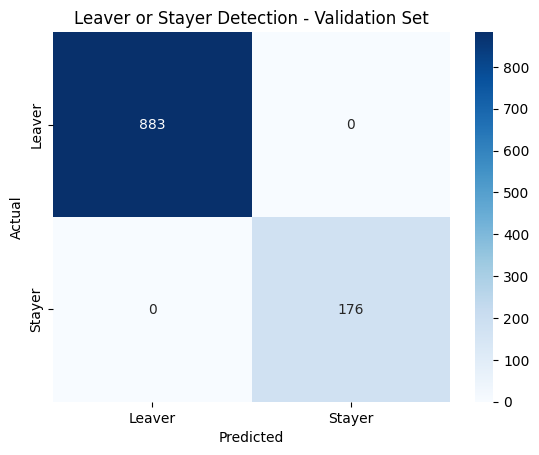

Classification Report for Validation Set:
              precision    recall  f1-score   support

      Leaver       1.00      1.00      1.00       883
      Stayer       1.00      1.00      1.00       176

    accuracy                           1.00      1059
   macro avg       1.00      1.00      1.00      1059
weighted avg       1.00      1.00      1.00      1059



In [89]:
# Predict and evaluate the model on the validation set
multi_predictions = rf_model_multi.predict(multi_val_X)
accuracy = accuracy_score(multi_val_Y, multi_predictions)
precision = precision_score(multi_val_Y, multi_predictions, average='weighted')
recall = recall_score(multi_val_Y, multi_predictions, average='weighted')
f1 = f1_score(multi_val_Y, multi_predictions, average='weighted')
print(f"Validation Set Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Confusion Matrix for Validation Set
conf_matrix = confusion_matrix(multi_val_Y, multi_predictions)
class_labels = ['Leaver', 'Stayer']
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Leaver or Stayer Detection - Validation Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report for Validation Set
print("Classification Report for Validation Set:")
print(classification_report(multi_val_Y, multi_predictions, target_names=class_labels))


Test Set Evaluation:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


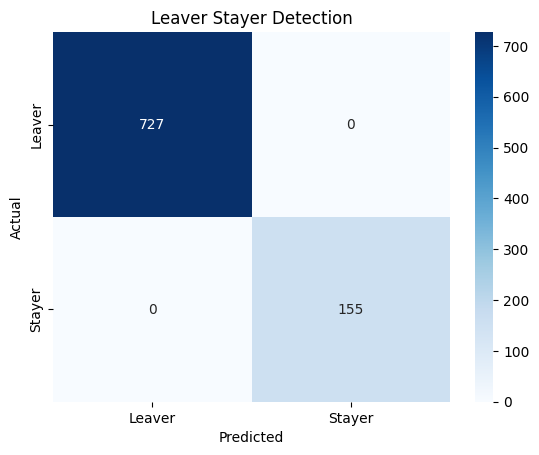

Classification Report for Test Set:
              precision    recall  f1-score   support

      Leaver       1.00      1.00      1.00       727
      Stayer       1.00      1.00      1.00       155

    accuracy                           1.00       882
   macro avg       1.00      1.00      1.00       882
weighted avg       1.00      1.00      1.00       882



In [90]:
# Final evaluation on the test set
test_multi_predictions = rf_model_multi.predict(test_X)
test_accuracy = accuracy_score(test_Y, test_multi_predictions)
test_precision = precision_score(test_Y, test_multi_predictions, average='weighted')
test_recall = recall_score(test_Y, test_multi_predictions, average='weighted')
test_f1 = f1_score(test_Y, test_multi_predictions, average='weighted')
print("\nTest Set Evaluation:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")

# Confusion Matrix for Test Set
test_conf_matrix = confusion_matrix(test_Y, test_multi_predictions)
sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Leaver Stayer Detection')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report for Test Set
print("Classification Report for Test Set:")
print(classification_report(test_Y, test_multi_predictions, target_names=class_labels))